In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
pd.options.mode.chained_assignment = None

# sctrial: Stress Test and Scalability Analysis

This notebook demonstrates `sctrial`'s performance and scalability by running a stress test on a large-scale synthetic dataset (e.g., 20,000 cells and 10,000 genes).


In [2]:
import sctrial as st
import numpy as np
import pandas as pd
from anndata import AnnData
from scipy import sparse
import time
import matplotlib.pyplot as plt


## 1. Dataset Generation
We generate a dataset with 50 participants and 10,000 genes to simulate the scale of a real clinical trial.


In [3]:
n_participants = 50
n_cells_per_unit = 200
n_genes = 10000

print(f"Generating stress-test dataset: {n_participants} participants, {n_genes} genes...")

rows = []
for i in range(n_participants):
    arm = "Treated" if i < n_participants // 2 else "Control"
    for v in ["Baseline", "Followup"]:
        for _ in range(n_cells_per_unit):
            rows.append({
                "participant_id": f"P{i}",
                "visit": v,
                "arm": arm,
                "celltype": "TypeA" if np.random.rand() > 0.5 else "TypeB",
                "batch": f"B{i % 5}"
            })

obs = pd.DataFrame(rows)
n_obs = len(obs)

# Generate sparse noisy data
data = np.random.poisson(0.1, size=(n_obs, n_genes)).astype(float)
# Inject signal in some genes
data[obs[(obs["arm"]=="Treated") & (obs["visit"]=="Followup")].index, :10] += 2.0
X = sparse.csr_matrix(data)

adata = AnnData(X=X, obs=obs)
adata.var_names = [f"Gene{i}" for i in range(n_genes)]
adata.layers["counts"] = adata.X.copy()

print(adata)


Generating stress-test dataset: 50 participants, 10000 genes...


AnnData object with n_obs × n_vars = 20000 × 10000
    obs: 'participant_id', 'visit', 'arm', 'celltype', 'batch'
    layers: 'counts'


## 2. Benchmark: Normalization
We measure the time taken to normalize 20,000 cells x 10,000 genes.


In [4]:
design = st.TrialDesign(
    participant_col="participant_id",
    visit_col="visit",
    arm_col="arm",
    arm_treated="Treated",
    arm_control="Control"
)

print("Normalizing...")
start_norm = time.time()
adata = st.add_log1p_cpm_layer(adata, counts_layer="counts", out_layer="log1p_cpm")
time_norm = time.time() - start_norm
print(f"Done in {time_norm:.2f}s")


Normalizing...


Done in 0.20s


## 3. Benchmark: Large-Scale DiD Analysis
We run DiD across a range of gene counts to evaluate scaling behavior.


Running DiD on 10 genes...


Running DiD on 50 genes...


Running DiD on 100 genes...


Running DiD on 200 genes...


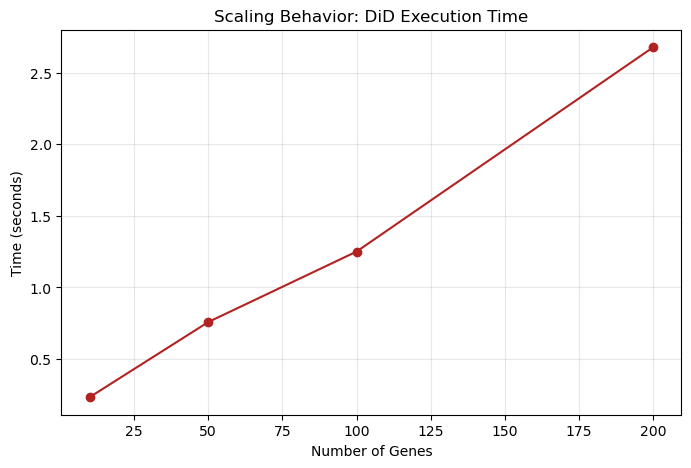

In [5]:
gene_counts = [10, 50, 100, 200]
times = []

for gc in gene_counts:
    print(f"Running DiD on {gc} genes...")
    start = time.time()
    _ = st.did_table(
        adata, 
        features=adata.var_names[:gc], 
        design=design, 
        visits=("Baseline", "Followup"),
        layer="log1p_cpm"
    )
    times.append(time.time() - start)

plt.figure(figsize=(8, 5))
plt.plot(gene_counts, times, marker='o', linestyle='-', color='firebrick')
plt.title("Scaling Behavior: DiD Execution Time")
plt.xlabel("Number of Genes")
plt.ylabel("Time (seconds)")
plt.grid(True, alpha=0.3)
plt.show()


## 4. Benchmark: Stratified DiD Analysis
Testing performance of stratified analysis across cell types.


In [6]:
print("Running stratified DiD (10 genes x 2 celltypes)...")
start_strat = time.time()
strat_res = st.did_table_by_celltype(
    adata,
    features=adata.var_names[:10],
    design=design,
    visits=("Baseline", "Followup"),
    layer="log1p_cpm"
)
time_strat = time.time() - start_strat
print(f"Done in {time_strat:.2f}s")


Running stratified DiD (10 genes x 2 celltypes)...


Done in 0.53s


## 5. Results Summary



Summary of Results:
## Trial-Aware DiD Summary
Total features tested: 100
Significant (p < 0.05): 11
Significant (FDR < 0.05): 11

### Top Upregulated Features (by p-value):
- Gene0: beta=2.289, p=0.00e+00
- Gene1: beta=2.276, p=0.00e+00
- Gene2: beta=2.306, p=0.00e+00

### Top Downregulated Features (by p-value):
- Gene38: beta=-1.001, p=6.38e-02
- Gene90: beta=-0.941, p=8.94e-02
- Gene96: beta=-0.681, p=2.36e-01


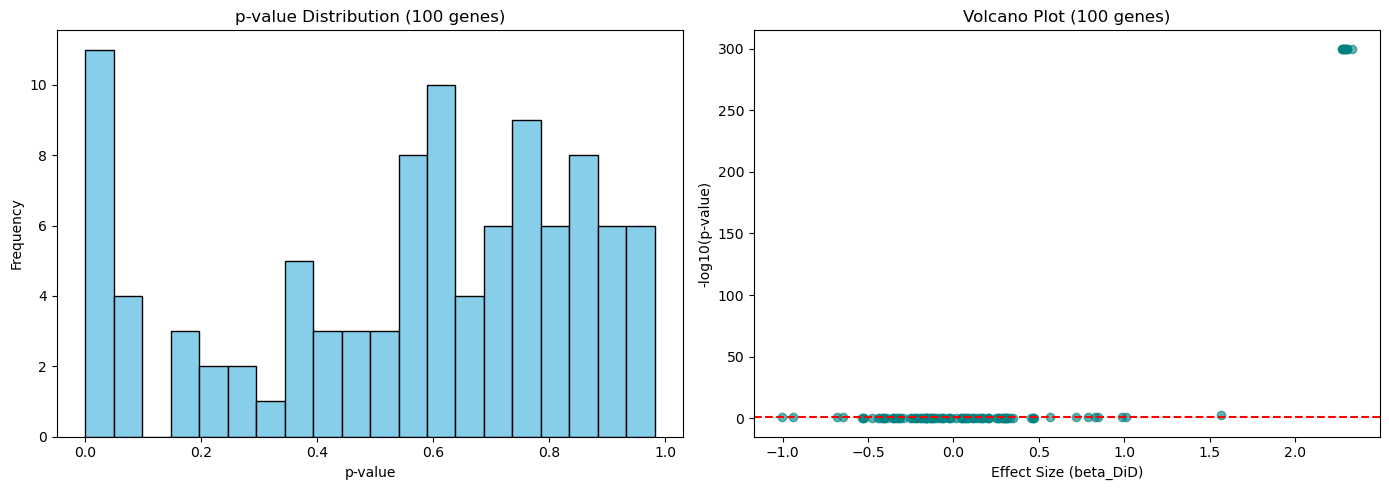


Final Performance Metrics:
- Normalization (20k cells x 10k genes): 0.20s
- Stratified DiD (10 genes x 2 types): 0.53s
- Single Gene DiD (avg): 0.0061s

Stress test passed successfully!


In [7]:
res = st.did_table(
    adata, 
    features=adata.var_names[:100], 
    design=design, 
    visits=("Baseline", "Followup"),
    layer="log1p_cpm"
)

print("\nSummary of Results:")
print(st.summarize_did_results(res))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# p-value distribution
axes[0].hist(res["p_DiD"], bins=20, color="skyblue", edgecolor="black")
axes[0].set_title("p-value Distribution (100 genes)")
axes[0].set_xlabel("p-value")
axes[0].set_ylabel("Frequency")

# Volcano plot
res_v = st.plotting.did_volcano_frame(res)
axes[1].scatter(res_v["beta_DiD"], res_v["neglog10p"], alpha=0.6, color="teal")
axes[1].axhline(-np.log10(0.05), color="red", linestyle="--")
axes[1].set_title("Volcano Plot (100 genes)")
axes[1].set_xlabel("Effect Size (beta_DiD)")
axes[1].set_ylabel("-log10(p-value)")

plt.tight_layout()
plt.show()

print(f"\nFinal Performance Metrics:")
print(f"- Normalization (20k cells x 10k genes): {time_norm:.2f}s")
print(f"- Stratified DiD (10 genes x 2 types): {time_strat:.2f}s")
print(f"- Single Gene DiD (avg): {np.mean(times)/gene_counts[-1]:.4f}s")

print("\nStress test passed successfully!")
